<a href="https://colab.research.google.com/github/123chri/Machine-Learning-with-Python-Bootcamp/blob/main/ML_with_Python_Mini_Hackathon_Team_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

EDA & Data Cleaning

In [ ]:
import pandas as pd
import numpy as np
#-- Load --
url = ('https://raw.githubusercontent.com/123chri/Machine-Learning-with-Python-Bootcamp/refs/heads/main/dirty_cafe_sales.csv')
df = pd.read_csv(url)

# -- Inspect --
print("=== ORIGINAL DATA ===")
print("\n")
print("Shape:", df.shape)
print("\n")
print(df.head())
print("\n")
print(df.info())
print("\n")
print(df.isnull().sum())
print("\n")
print(df.describe())
print("\n")

# -- Clean --
# 1. Replace 'ERROR' with NaN
df = df.replace('ERROR', np.nan)

#2. Convert numeric columns
df['Quantity'] =pd.to_numeric(df['Quantity'], errors='coerce')
df['Price Per Unit'] =pd.to_numeric(df['Price Per Unit'], errors='coerce')
df['Total Spent'] =pd.to_numeric(df['Total Spent'], errors='coerce')

# 3. Fill missing numeric values with MEDIAN
df['Quantity'] = df['Quantity'].fillna(df['Quantity'].median())
df['Price Per Unit'] = df['Price Per Unit'].fillna(df['Price Per Unit'].median())
df['Total Spent'] = df['Total Spent'].fillna(df['Total Spent'].median())
# 4. Fill missing categorical values with MODE
for col in ['Item', 'Payment Method', 'Location']:
  mode_val = df[col].mode () [0]
  df[col] = df[col].fillna(mode_val)





  # 5. Remove outlier rows (Quantity > 20)
  df_clean = df[df['Quantity'] <= 20]

  # -- Verify --
  print("\n=== CLEANED DATA ===")
  print(f"Rows before {len(df)}")
  print(f"Rows after: {len(df_clean)}")
  print(df_clean.describe())

  # -- Save--
  df_clean.to_csv('clean_cafe_200.csv', index=False)

=== ORIGINAL DATA ===


Shape: (200, 7)


  ﻿Transaction ID    Item  Quantity  Price Per Unit Total Spent  \
0         TXN_001  Coffee         2             2.0         4.0   
1         TXN_002    Cake         4             3.0        12.0   
2         TXN_003  Cookie         4             1.0       ERROR   
3         TXN_004   Salad         2             5.0        10.0   
4         TXN_005  Coffee         2             2.0         4.0   

   Payment Method  Location  
0     Credit Card  Takeaway  
1            Cash  In-store  
2     Credit Card  In-store  
3         UNKNOWN   UNKNOWN  
4  Digital Wallet  In-store  


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ﻿Transaction ID  200 non-null    object 
 1   Item             199 non-null    object 
 2   Quantity         200 non-null    int64  
 3   Price Per Unit   200 non-null    f

Building a Logistic Regression Classifier


# Part:1 Answers
#Q1
There were 200 rows in the original data set.
199 rows remained after cleaning the data set.

#Q2
20 median values were used to fill missing quantity values.

#Q3
We removed rows where quantity was greater than 20 to eliminates unrealistic data entry errors and extreme business anomalies that would otherwise distort your averages and confuse machine learning models.

#Q4
We use median instead of mean because the median is used to find the exact middle value of our data, preventing extreme outliers or typos from distorting our filled-in missing numbers.

MODEL PERFORMANCE ON TEST DATA
Accuracy:  80.00%
Precision: 1.0000
Recall:    0.4872
F1-Score:  0.6552

Confusion Matrix:
[[61  0]
 [20 19]]


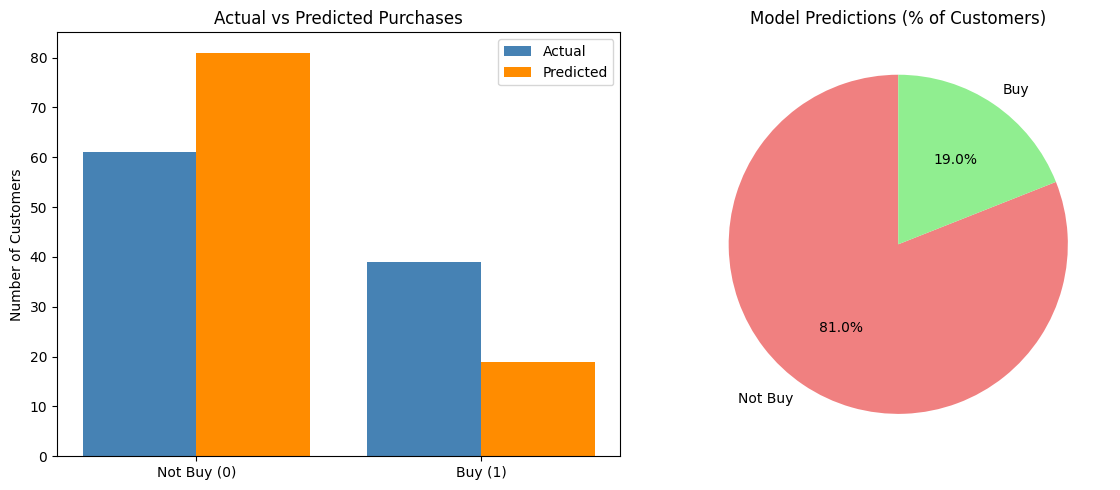

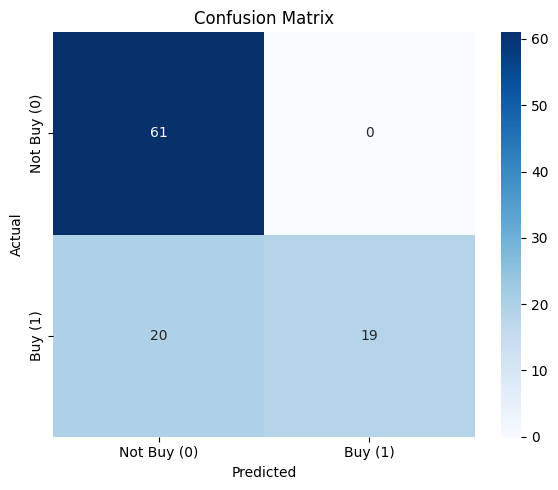


Saved: model.pkl  |  scaler.pkl


In [ ]:
# PART 2: LOGISTIC REGRESSION – TRAIN, EVALUATE, SAVE

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             precision_score, recall_score, f1_score)
import seaborn as sns # Import seaborn for heatmap

# 1. Load dataset
from google.colab import files
uploaded = files.upload()
df = pd.read_csv('https://raw.githubusercontent.com/123chri/Machine-Learning-with-Python-Bootcamp/refs/heads/main/DigitalAd_dataset.csv')

# 2. Prepare features and target
X = df[['Age', 'Salary']]    # features
y = df['Status']           # target

# 3. Train / test split (75 / 25)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=0)

# 4. Scale features (fit only on training data!)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# 5. Train logistic regression
model = LogisticRegression(random_state=0)
model.fit(X_train_scaled, y_train)

# 6. Predict
y_pred  = model.predict(X_test_scaled)
y_proba = model.predict_proba(X_test_scaled)[:, 1]

# 7. Evaluation metrics
print("=" * 50)
print("MODEL PERFORMANCE ON TEST DATA")
print("=" * 50)
print(f"Accuracy:  {accuracy_score(y_test, y_pred)*100:.2f}%")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred):.4f}")
print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred) # Define cm here
print(cm)

# 8. Plot 1 – Actual vs Predicted counts
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
categories   = ['Not Buy (0)', 'Buy (1)']
actual_counts = [sum(y_test == 0), sum(y_test == 1)]
pred_counts   = [sum(y_pred == 0), sum(y_pred == 1)]
x = range(len(categories))
plt.bar(x, actual_counts, width=0.4, label='Actual',    color='steelblue')
plt.bar([i+0.4 for i in x], pred_counts, width=0.4, label='Predicted', color='darkorange')
plt.xticks([i+0.2 for i in x], categories)
plt.ylabel('Number of Customers')
plt.title('Actual vs Predicted Purchases')
plt.legend()

# 9. Plot 2 – Pie Chart of Predictions
plt.subplot(1,2,2)
buy_count = sum(y_pred == 1)
not_buy_count = sum(y_pred == 0)
plt.pie([not_buy_count, buy_count], labels=['Not Buy', 'Buy'],
        autopct='%1.1f%%', colors=['lightcoral', 'lightgreen'], startangle=90)
plt.title('Model Predictions (% of Customers)')

plt.tight_layout()
plt.show()

# 9. Plot 3 – VISUALIZATION 3: Confusion Matrix Heatmap
plt.figure(figsize=(6, 5)) # Create a new figure for the heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Buy (0)', 'Buy (1)'],
            yticklabels=['Not Buy (0)', 'Buy (1)'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')

plt.tight_layout()
plt.show()


# 10. Save the model and scaler
joblib.dump(model,  'model.pkl')
joblib.dump(scaler, 'scaler.pkl')
print("\nSaved: model.pkl  |  scaler.pkl")

#Part:2 Answers
#Q1
Our model printed a 80.00% accuracy.

#Q2
The two correct prediction numbers in the confusion matrix are "61 & 19".

#Q3
No, they are not roughly the same height. The blue actual bar for the buy group is significally taller (representing 39 total actual buyers) than the orange "Predicted" bar (representing only 19 predicted buyers).

#Q4
B) So Age and Salary have equal importance in the model.

#Q5
These files are used to allow you save your hard work so you can load them later into a web app or script to make instant predictions on new data without needing to retain the model from scratch.


